# Предсказание стоимости жилья

Необходимо обучить модель линейной регрессии на данных о жилье в Калифорнии в 1990 году и предсказать медианную стоимость дома в жилом массиве.

## Описание проекта

**Заказчик**

Потеницальный покупатель


**Входные данные**

Данные о жилье в Калифорнии в 1990 году - местоположение, возраст жилья, харакетиристики жилья


**Задача**

Обучите модель, выбрать лучшую на основе RMSE, MAE и R2, и сделать предсказания на тестовой выборке


**Цель**

Помочь потенциальному покупателю оценить стоимость квартиры на основе ее признаков для сравнения с ценой продавца или для оценки на продажу

**Описание входных данных**

- `longitude` — широта
- `latitude` — долгота
- `housing_median_age` — медианный возраст жителей жилого массива
- `total_rooms` — общее количество комнат в домах жилого массива
- `total_bedrooms` — общее количество спален в домах жилого массива
- `population` — количество человек, которые проживают в жилом массиве
- `households` — количество домовладений в жилом массиве
- `median_income` — медианный доход жителей жилого массива
- `median_house_value` — медианная стоимость дома в жилом массиве
- `ocean_proximity` — близость к океану


Данные о жилье `/datasets/housing.csv`

In [1]:
!pip install numba==0.57.1 -q
!pip install --upgrade pyspark -q
!pip install pingouin -q
!pip install phik -q
!pip install histogrammar -q 
#Запустить сессию с конфигом не получилось, чтобы скачивал автоматически и нагуглить не вышло в чем дело, поэтому
# Поэтому пришлось скачать вручную jarы и закинуть на сервер

In [2]:
import pandas as pd
import numpy as np
import itertools

# графики
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm

#pyspark
import pyspark
from pyspark.context import SparkContext
from pyspark.sql import SparkSession
from pyspark.sql.types import *
import pyspark.sql.functions as F

#pyspark_ml
from pyspark.ml.clustering import KMeans
from pyspark.ml.regression import (
    LinearRegression, 
    GeneralizedLinearRegression)
from pyspark.ml.evaluation import (
    ClusteringEvaluator, 
    RegressionEvaluator)
from pyspark.ml.feature import (
    StringIndexer, 
    VectorAssembler, 
    StandardScaler, 
    OneHotEncoder)
from pyspark.ml import Pipeline
from pyspark.ml.tuning import (
    CrossValidator, 
    ParamGridBuilder)

import pingouin as pg
import histogrammar as hg
from histogrammar.plot.hist_numpy import get_2dgrid
import phik
from phik import resources
from phik.phik import spark_phik_matrix_from_hist2d_dict

RANDOM_STATE = 42

pd.set_option('display.max_colwidth', 80)

In [3]:
# запускаем Spark сессию
spark = SparkSession.builder \
                    .master("local") \
                    .appName('EDA California Housing') \
                    .config('spark.sql.repl.eagerEval.enabled', True) \
                    .config('spark.jars', 
                            '''/home/jovyan/work/histogrammar_2.12-1.0.30.jar,
                            /home/jovyan/work/histogrammar-sparksql_2.12-1.0.30.jar''') \
                    .getOrCreate()

# для нормального запуска должно быть так, если не у тебя не запускается
# попробуй раскоментить это, а выше закоментить
#scala = '2.12' if int(pyspark_version[0]) >= 3 else '2.11'
#hist_jar = f'io.github.histogrammar:histogrammar_{scala}:1.0.20'
#hist_spark_jar = f'io.github.histogrammar:histogrammar-sparksql_{scala}:1.0.20'
#spark = SparkSession.builder \
#                    .master("local") \
#                    .appName('EDA California Housing') \
#                    .config('spark.sql.repl.eagerEval.enabled', True) \
#                    .config('spark.jars.packages', f'{hist_spark_jar},{hist_jar}') \
#                    .getOrCreate()

sc = spark.sparkContext
sc.setLogLevel("ERROR")

24/10/24 13:26:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


## Разведочный анализ

Импортируем данные

In [4]:
df_housing = spark.read.csv('/datasets/housing.csv', inferSchema=True, header=True)

In [5]:
pd.DataFrame(df_housing.dtypes, columns=['column', 'type'])

,column,type
0,longitude,double
1,latitude,double
2,housing_median_age,double
3,total_rooms,double
4,total_bedrooms,double
5,population,double
6,households,double
7,median_income,double
8,median_house_value,double
9,ocean_proximity,string


Все столбцы импортировались корректно, все признаки числовые, кроме `ocean_proximity` - строковый

In [6]:
df_housing.limit(5)

longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
df_housing.summary().toPandas()

,summary,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,count,20640,20640,20640,20640,20433,20640,20640,20640,20640,20640
1,mean,-119.56970445736148,35.6318614341087,28.639486434108527,2635.7630813953488,537.8705525375618,1425.4767441860465,499.5396802325581,3.8706710029070246,206855.81690891474,None
2,stddev,2.003531723502584,2.135952397457101,12.58555761211163,2181.6152515827944,421.38507007403115,1132.46212176534,382.3297528316098,1.899821717945263,115395.61587441359,None
3,min,-124.35,32.54,1.0,2.0,1.0,3.0,1.0,0.4999,14999.0,<1H OCEAN
4,25%,-121.8,33.93,18.0,1447.0,296.0,787.0,280.0,2.5625,119600.0,None
5,50%,-118.49,34.26,29.0,2127.0,435.0,1166.0,409.0,3.5347,179700.0,None
6,75%,-118.01,37.71,37.0,3146.0,647.0,1724.0,605.0,4.7426,264700.0,None
7,max,-114.31,41.95,52.0,39320.0,6445.0,35682.0,6082.0,15.0001,500001.0,NEAR OCEAN


**Вывод**

- В таблице 20640 записей
- 9 числовых признаков
- 1 строковый - `ocean_proximity`

## Предобработка данных

Посмотрим на наличие пропусков

In [8]:
df_housing.select([F.count(F.when(F.col(c).contains('None') | \
                                  F.col(c).contains('NULL') | \
                                  (F.col(c) == '') | \
                                  F.col(c).isNull() | \
                                  F.isnan(c), c)).alias(c)
                   for c in df_housing.columns])

longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,0,0,0,207,0,0,0,0,0


Есть 207 пропусков в `total_bedrooms` - заполним их далее

Проверим данные на полные дубликаты

In [9]:
df_housing.distinct().count()

20640

Их нет, отлично

**Вывод**
- Есть 207 пропусков в `total_bedrooms` - заполним их позже
- Полных дубликатов нет

## Иследовательский анализ

In [10]:
sns.set(font_scale=1.2)
sns.set_style('whitegrid', {'axes.edgecolor': 'black'})

# Определим функцию для графического и описательного анализа столбцов
def describe_column(data, explode=None):

    # Условие на тип диаграммы не категориальной без сравнения:

    if (data.dtype != object):
        fig = plt.figure(figsize=(20,6))

        # Настройки сетки графика
        gs = gridspec.GridSpec(2, 2, height_ratios=[5, 1])
        gs.update(hspace=0)
        ax_hist = plt.subplot(gs[0, 0])
        ax_box = plt.subplot(gs[1, 0])
        ax_qq = plt.subplot(gs[:, 1])

        # Boxplot и гистограмма
        sns.boxplot(x=data, ax=ax_box)
        sns.histplot(x=data,
                     bins='sturges',
                     alpha=1,
                     edgecolor='black',
                     ax=ax_hist,
                     stat='probability')
        plt.subplots_adjust(hspace=0)
        ax_hist.set_ylabel('Частота', size=14)
        ax_hist.set_title(f'Распределение признака {data.name}', size=14)

        # QQ-plot
        pg.qqplot(data, ax=ax_qq, square=False)
        ax_qq.set_title(f'Нормальный график Q-Q признака {data.name}', size=14)
        ax_qq.set_xlabel('Нормальные квантили', size=14)
        ax_qq.set_ylabel('Признаковые квантили', size=14)

        plt.show()

        # Описательная статистика
        display(pd.DataFrame(data.describe()).T)

    # Условие на категориальный тип диаграммы
    else:
        data.value_counts().plot(kind='pie', explode=explode,
                                 autopct=make_autopct(data.value_counts()),
                                 fontsize=12, figsize=(6, 6))
        plt.title(f'Распределение признака {data.name}', fontsize=12)
        plt.ylabel('')

# создадим дополнтильную функцию для вывода количества элементов в блоке для графика pie
# возвращает подпись элемента в % и число
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{p:.2f}%\n({v:d})'.format(p=pct,v=val)
    return my_autopct

### Координаты массива

Так как в Калифорнии есть несколько крупных городов вроде ЛА или СФ на побережье, а есть поменьше и подешевле - Сан-Диего, например, попробуем кластеризовать координаты на зоны и перевести эти два признака в 1 категориальный, если хорошо кластеризуется

In [11]:
# собираем координаты в векторный признак для кластеризации
df_housing = VectorAssembler(inputCols=['longitude', 'latitude'], 
                        outputCol="coord_features").transform(df_housing)

In [12]:
# для подбора оптимального k (от 3 до 20) будем пользоваться методом локтя
topk = 20
# построим словарь k : inertia - меру разброса внутри кластера
elbow = {
    k: (
        KMeans()
        .setK(k)
        .setSeed(RANDOM_STATE)
        .setFeaturesCol('coord_features')
        .setMaxIter(300)
        .setInitSteps(10)
        .fit(df_housing)
        .summary.trainingCost
        ) for k in range(3, topk)}

elbow_df = pd.DataFrame(elbow, index=['inertia']).T

,inertia,elbow_vel,elbow_acc
3,18287.010668,-4024.347362,3070.738172
4,14262.663306,-953.609190,-2950.497378
5,13309.054117,-3904.106568,1593.128882
6,9404.947549,-2310.977685,1261.032920
7,7093.969864,-1049.944765,555.712914
8,6044.025098,-494.231852,56.890321
9,5549.793247,-437.341530,29.932767
10,5112.451717,-407.408764,-28.324495
11,4705.042953,-435.733259,-166.040532
12,4269.309694,-601.773791,351.912663


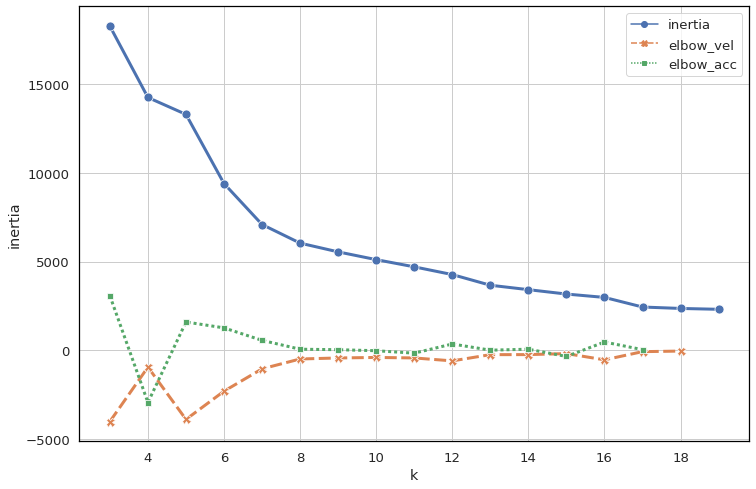

In [13]:
# посчитаем скорость изменения локтя для каждого шага
elbow_vel = {k: np.divide(elbow[k+1] - elbow[k], k+1 - k) for k in range(3, topk-1)}
elbow_df['elbow_vel'] = pd.DataFrame(elbow_vel, index=['elbow_vel']).T

# посчитаем ускорение изменения локтя для каждого шага
elbow_acc = {k: np.divide(elbow_vel[k+1] - elbow_vel[k], k+1 - k) for k in range(3, topk-2)}
elbow_df['elbow_acc'] = pd.DataFrame(elbow_acc, index=['elbow_acc']).T

# построим график и таблицу
fig = plt.figure(figsize=(12,8))
sns.lineplot(data=elbow_df, markers=True, linewidth=3, markersize=9)
plt.ylabel('inertia')
plt.xlabel('k')
elbow_df

Подходящие k - 9, 13 и 17. Там изменение меньше всего. Попробуем посмотреть графически, но скорее всего подойдет 13 или 17

In [14]:
# фрейм из координат
coords = df_housing.select('longitude', 'latitude').toPandas()
dict_ = {i: ch for i,ch in enumerate('abcdefghiklmnopqrstuvwxyz')}

def california_clust(c):
    dict_ = {i: ch for i,ch in enumerate('abcdefghiklmnopqrstuvwxyz')}
    
    fig = plt.figure(figsize=(8,8))
    sns.scatterplot(data=coords, 
                    x='longitude', 
                    y='latitude', 
                    hue='coord_centroid_id', 
                    alpha=0.5, 
                    palette='tab20', 
                    legend=False)
    
    # промаркируем центроиды кластеров
    textCoord = [dict_[i] for i in range(len(kmeans.clusterCenters()))]
    x, y = np.array(kmeans.clusterCenters()).T
    for col, row, t in zip(x, y, textCoord):
        plt.text(col, row, t, fontsize=15, color='black', weight='bold')
        
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(False)
    plt.title(f'{k}-кластерное разбиение Калифорнии')
    plt.show();

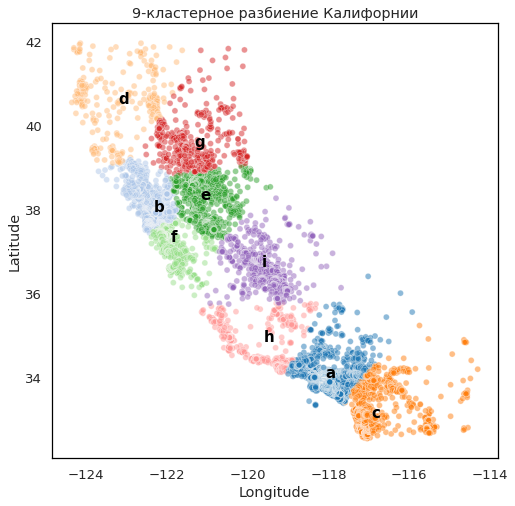

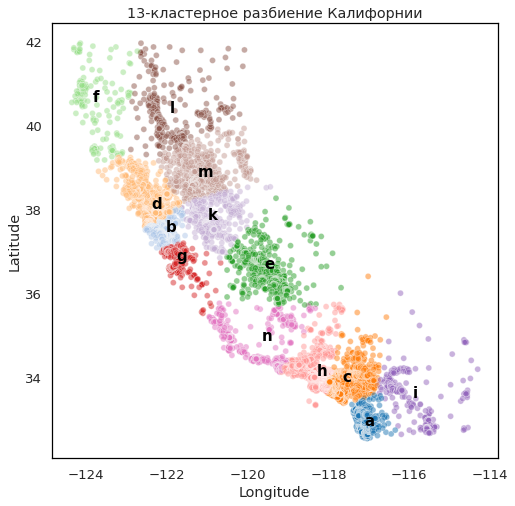

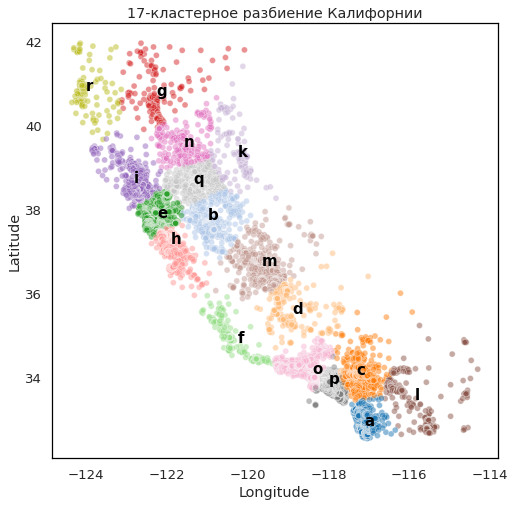

In [15]:
for k in [9, 13, 17]:
    kmeans = (
        KMeans()
        .setK(k)
        .setSeed(RANDOM_STATE)
        .setFeaturesCol('coord_features')
        .setMaxIter(300)
        .setInitSteps(10)
        .setSolver('row')
        .fit(df_housing))
    coords['coord_centroid_id'] = kmeans.transform(df_housing).select('prediction').toPandas()
    california_clust(coords)

Видно, что на 9 слишком большие районы, на 13 - не выделяется например ЛА, а 17 подходит лучше всего

In [16]:
kmeans = (
        KMeans()
        .setK(17)
        .setSeed(RANDOM_STATE)
        .setFeaturesCol('coord_features')
        .setMaxIter(300)
        .setInitSteps(10)
        .setSolver('row')
        .fit(df_housing))

In [17]:
df_housing = kmeans.transform(df_housing)
df_housing = df_housing.withColumnRenamed('prediction', 'geocluster')
dict_ = {str(i): ch for i,ch in enumerate('abcdefghiklmnopqrstuvwxyz')}
df_housing = (df_housing.withColumn('geocluster', F.col('geocluster').cast('string'))
              .replace(dict_))
df_housing = df_housing.drop('longitude', 'latitude', 'coord_features')
df_housing.limit(5)

housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,geocluster
41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,e
21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,e
52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,e
52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,e
52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,e


In [18]:
del coords
del kmeans

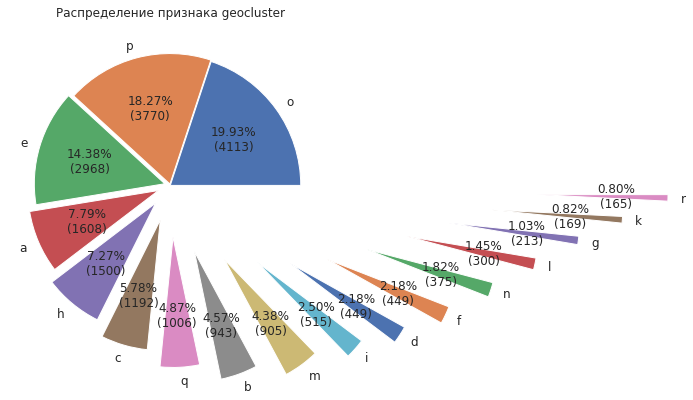

In [19]:
describe_column((df_housing.select('geocluster').toPandas())['geocluster'], 
                explode=[0.011*i**2 for i in range(17)])

Больше всего домовладений в кластере `o`, `p` и `e` - пригород ЛА, сам ЛА и Сан-Франциско

### `housing_median_age`

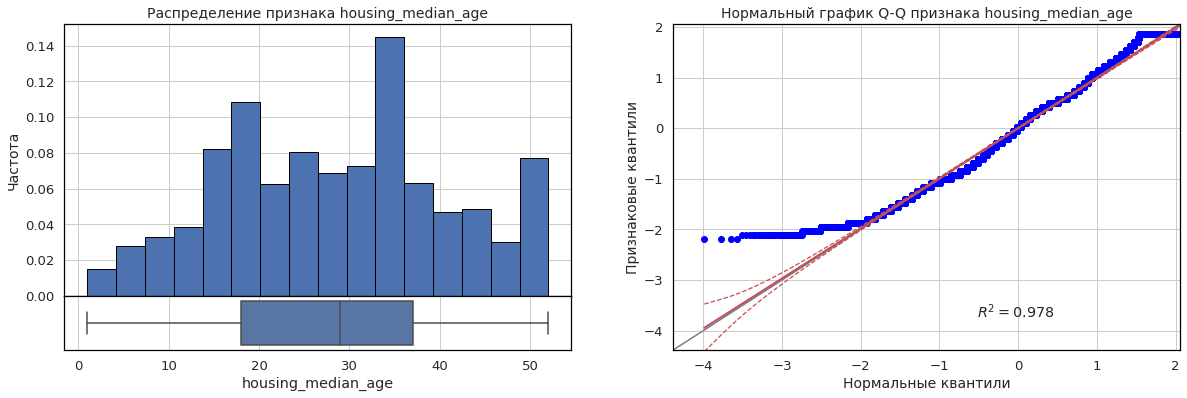

,count,mean,std,min,25%,50%,75%,max
housing_median_age,20640.0,28.639486,12.585558,1.0,18.0,29.0,37.0,52.0


In [20]:
describe_column((df_housing.select('housing_median_age').toPandas())['housing_median_age'])

В распределении видны периоды больших строек или застроек - пики около 15 и 33 лет назад и пик 52 года назад - в 1938 году получается, либо, данных о дате постройке нет или самострой и просто записывали максимальное значение, оставим как есть

Распределение в целом близкое к нормальному

### `total_rooms`

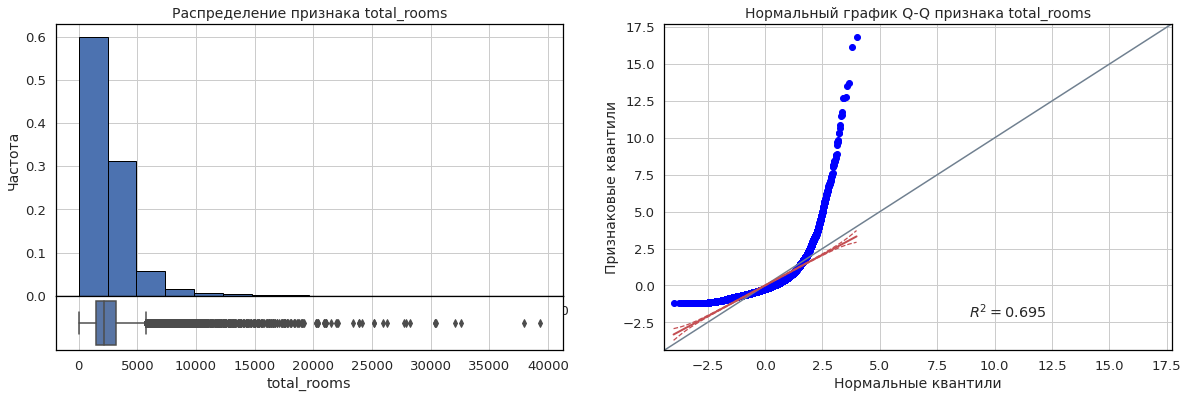

,count,mean,std,min,25%,50%,75%,max
total_rooms,20640.0,2635.763081,2181.615252,2.0,1447.75,2127.0,3148.0,39320.0


In [21]:
describe_column((df_housing.select('total_rooms').toPandas())['total_rooms'])

Распределение логнормальное

Так же добавим дополнительный признак `rooms_per_household` - отношение количества комнат `total_rooms` к количеству домовладений `households`

In [22]:
df_housing = df_housing.withColumn('rooms_per_household', 
                                   F.round(F.col('total_rooms') / F.col('households'), 2))

### `total_bedrooms`

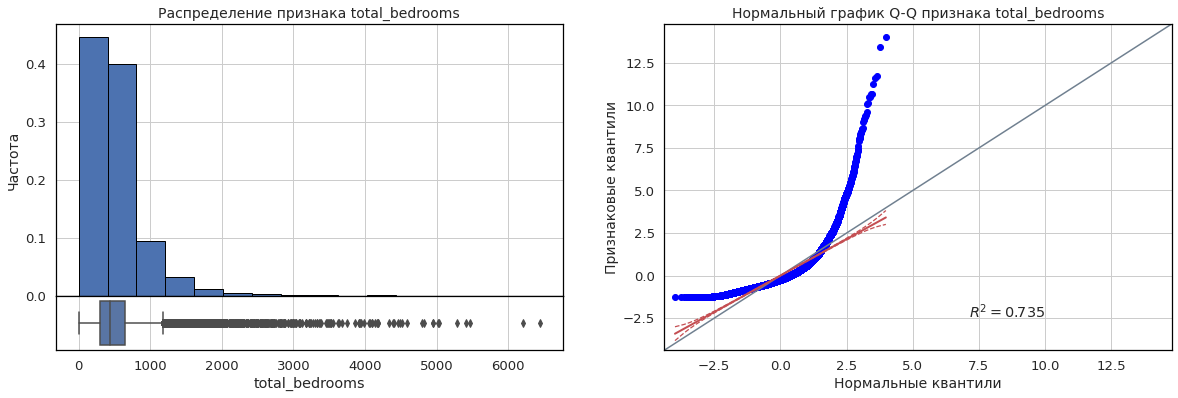

,count,mean,std,min,25%,50%,75%,max
total_bedrooms,20433.0,537.870553,421.38507,1.0,296.0,435.0,647.0,6445.0


In [23]:
describe_column((df_housing.select('total_bedrooms').toPandas())['total_bedrooms'])

Распределение логнормальное

Посмотрим на пропуски

In [24]:
df_housing.where(F.col("total_bedrooms").isNull()).limit(10)

housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,geocluster,rooms_per_household
47.0,1256.0,NULL,570.0,218.0,4.375,161900.0,NEAR BAY,e,5.76
38.0,992.0,NULL,732.0,259.0,1.6196,85100.0,NEAR BAY,e,3.83
29.0,5154.0,NULL,3741.0,1273.0,2.5762,173400.0,NEAR BAY,e,4.05
45.0,891.0,NULL,384.0,146.0,4.9489,247100.0,NEAR BAY,e,6.1
41.0,746.0,NULL,387.0,161.0,3.9063,178400.0,NEAR BAY,e,4.63
37.0,3342.0,NULL,1635.0,557.0,4.7933,186900.0,NEAR BAY,e,6.0
20.0,3759.0,NULL,1705.0,600.0,4.712,158600.0,INLAND,n,6.27
5.0,5526.0,NULL,3207.0,1012.0,4.0767,143100.0,INLAND,e,5.46
22.0,2987.0,NULL,1420.0,540.0,3.65,204100.0,INLAND,e,5.53
23.0,3741.0,NULL,1339.0,499.0,6.7061,322300.0,NEAR BAY,e,7.5


Ничего необычного, заменим пропуски количеством `households`, т.е. будем считать, что 1 спальня есть в каждом владении, так как не до конца понятна природа пропусков

In [25]:
df_housing = df_housing.withColumn('total_bedrooms', 
    F.coalesce(F.col('total_bedrooms'), F.col('households')))

Так же добавим дополнительный признак `bedroom_index` - отношение количества спален `total_bedrooms` к общему количеству комнат `total_rooms`

In [26]:
df_housing = df_housing.withColumn('bedroom_index', 
             F.round(F.col('total_bedrooms') / F.col('total_rooms'), 2))

### `population`

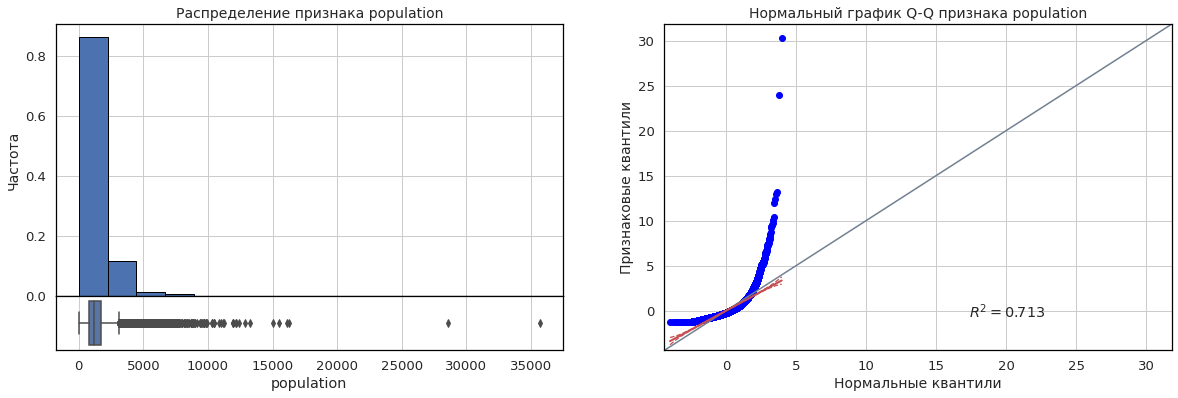

,count,mean,std,min,25%,50%,75%,max
population,20640.0,1425.476744,1132.462122,3.0,787.0,1166.0,1725.0,35682.0


In [27]:
describe_column((df_housing.select('population').toPandas())['population'])

Распределение логнормальное

Так же добавим дополнительный признак `population_in_household` - отношение количества жителей population к количеству домовладений households

In [28]:
df_housing = df_housing.withColumn('population_in_household', 
                                   F.round(F.col('population') / F.col('households'), 2))

### `households`

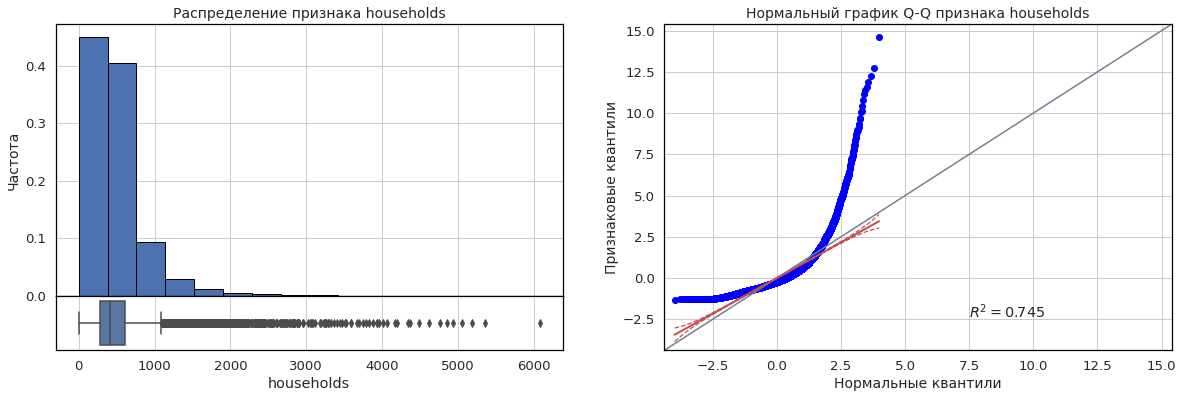

,count,mean,std,min,25%,50%,75%,max
households,20640.0,499.53968,382.329753,1.0,280.0,409.0,605.0,6082.0


In [29]:
describe_column((df_housing.select('households').toPandas())['households'])

Распределение похоже на логнормальное

### `median_income`

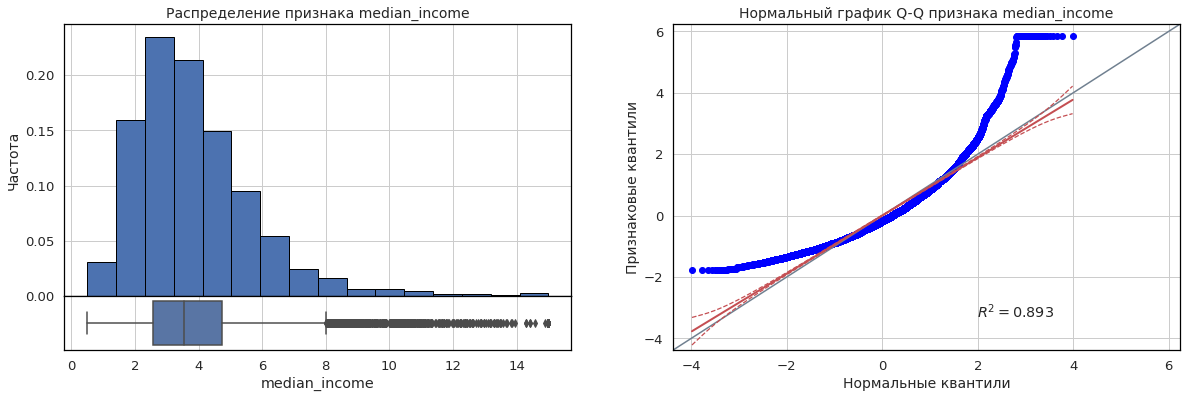

,count,mean,std,min,25%,50%,75%,max
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001


In [30]:
describe_column((df_housing.select('median_income').toPandas())['median_income'])

Распределение логнормальное, по своей природе, зарплаты генеральный совокупности распределены логнормально, поэтому добавим дополнительную переменную `median_income_log`

In [31]:
df_housing = df_housing.withColumn('median_income_log', 
             F.round(F.log(F.col('median_income')), 2))

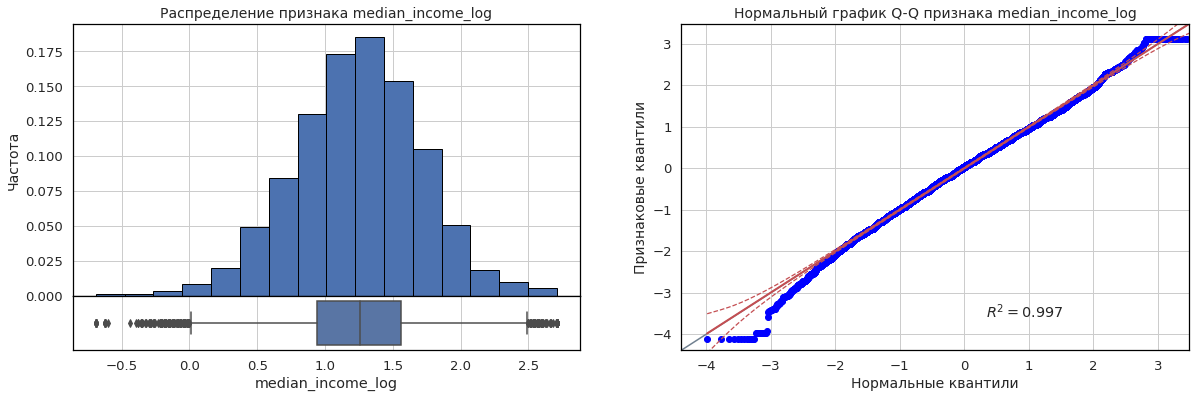

,count,mean,std,min,25%,50%,75%,max
median_income_log,20640.0,1.244454,0.470633,-0.69,0.94,1.26,1.56,2.71


In [32]:
describe_column((df_housing.select('median_income_log').toPandas())['median_income_log'])

### `median_house_value`

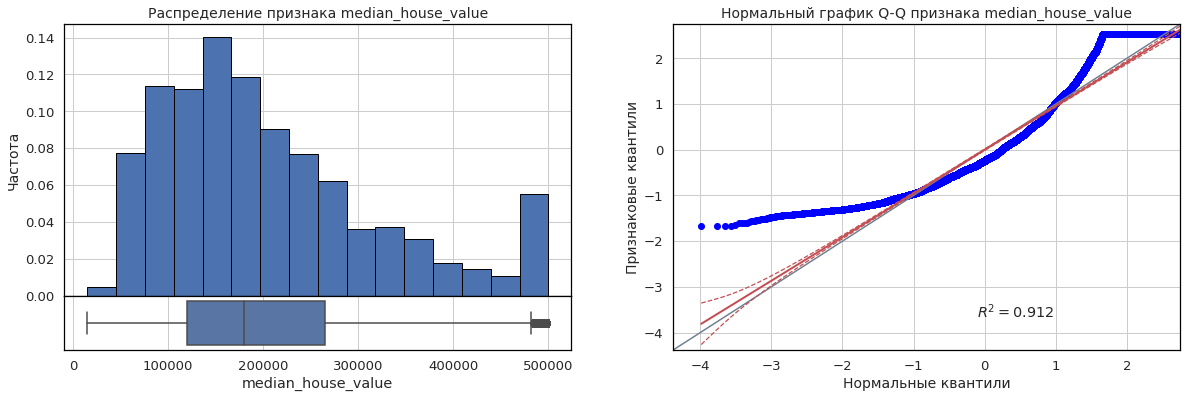

,count,mean,std,min,25%,50%,75%,max
median_house_value,20640.0,206855.816909,115395.615874,14999.0,119600.0,179700.0,264725.0,500001.0


In [33]:
describe_column((df_housing.select('median_house_value').toPandas())['median_house_value'])

Распределение тоже логнормальное, поэтому преобразовывать не будем, так как это по сути будет одинаковым преобразованием слева и справа в решении аналитеческого урванения - почти все признаки логнормальные и таргет

Потом будем использовать GLR со связью log вместо обычной LR

### `ocean_proximity`

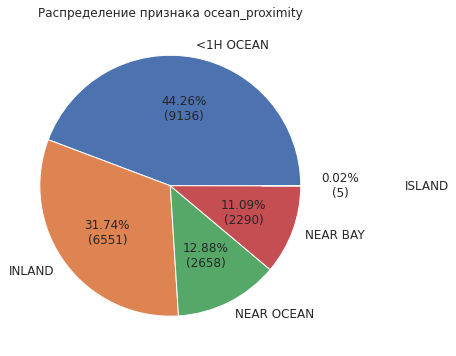

In [34]:
describe_column((df_housing.select('ocean_proximity').toPandas())['ocean_proximity'],
                explode=[0,0,0,0,0.7])

Больше всего массивов вблизи океана. Меньше всего на островах - 5, всего 0.02 %. Объединим категорию с `NEAR BAY`, потому что это скорее всего `Treasure Island`

In [35]:
df_housing = df_housing.withColumn('ocean_proximity', F.when(
    F.col('ocean_proximity')=="ISLAND", "NEAR BAY")
    .otherwise(df_housing['ocean_proximity']))

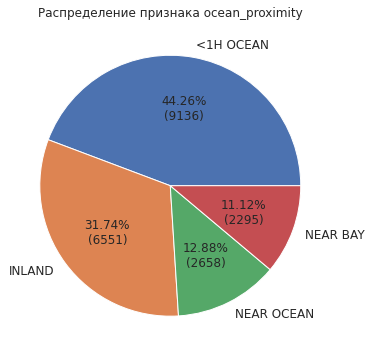

In [36]:
describe_column((df_housing.select('ocean_proximity').toPandas())['ocean_proximity'],
                explode=[0,0,0,0])

### Корреляционный анализ

In [37]:
combis = itertools.combinations_with_replacement(df_housing.columns, 2)
combis = [list(c) for c in combis]
hists = df_housing.hg_make_histograms(combis)
grids = {k:(get_2dgrid(h)[2]) for k,h in hists.items()}

100%|███████████████████████████████████████████████████████████████| 91/91 [00:10<00:00,  8.61it/s]


In [38]:
phik_matrix = spark_phik_matrix_from_hist2d_dict(sc, grids)

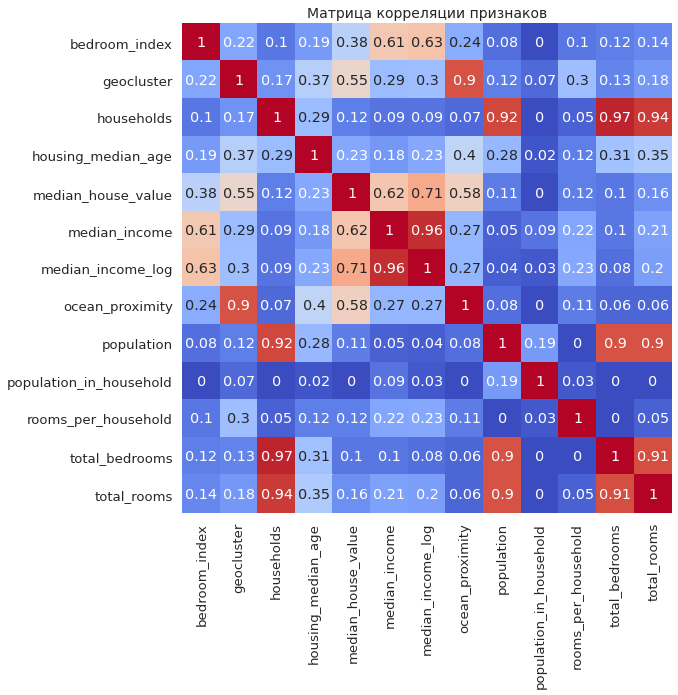

In [39]:
plt.figure(figsize=(9, 9))
plt.title('Матрица корреляции признаков',
          fontsize=14)
sns.heatmap(phik_matrix.round(2), 
            annot = True, square=True, 
            cmap='coolwarm', 
            cbar=False);

Сильная корреляция с целевым признаком у `bedroom_index`, `geocluster`, `median_income_log`, `ocean_proximity`

### Вывод

- Общие выводы
    - Касательно построения графиков, если бы массив был достаточно большой, то брали бы просто sample от него, чтобы посмотреть на распределение, матрицу корреляции построили через histogrammar
- Преобразовали `longitude` и `latitude` с помощью кластеризации в `geocluster`, разбив все координаты на 17 кластеров
- Так же добавили дополнительные признаки
    - `rooms_per_household` - отношение количества комнат к количеству домовладений
    - `bedroom_index` - отношение количества спален к общему количеству комнат
    - `population_in_household` - отношение количества жителей к количеству домовладений
    - `median_income_log` - так как генеральная совокупность доходов логнормальная
- Медианный портрет домовладения
    - возраст домовладения - 29 лет
    - количество комнат - 2127
    - спален - 435
    - жильцов - 1166
    - владений - 409
    - медианный доход жильцов - 3.5 тыс. USD в месяц
    - медианная стоимость жилья - 180 тыс. USD
    - менее часа езды от океана
    - находится где-то в пригороде ЛА или в самом Городе

## Обучение моделей

In [40]:
target = 'median_house_value'

cat_cols = [
    'geocluster',
    'ocean_proximity']

num_cols = [
    'housing_median_age',
    'total_rooms',
    'total_bedrooms',
    'population',
    'households',
    'median_income_log',
    'rooms_per_household',
    'bedroom_index',
    'population_in_household']

In [41]:
def lr_modeling(df_train, target, num_cols, cat_cols):
    si = StringIndexer(inputCols=cat_cols, 
                       outputCols=[c+'_idx' for c in cat_cols])

    ohe = OneHotEncoder(inputCols=[c+'_idx' for c in cat_cols],
                        outputCols=[c+'_ohe' for c in cat_cols],
                        dropLast=True)

    cat_assembler = VectorAssembler(inputCols=[c+'_ohe' for c in cat_cols],
                                     outputCol='cat_features')

    num_assembeler = VectorAssembler(inputCols=num_cols,
                                     outputCol='num_features')

    scaler = StandardScaler(inputCol='num_features', 
                            outputCol='num_features_scaled',
                            withMean=True,
                            withStd=True)

    fin_assembler = VectorAssembler(inputCols=['cat_features', 'num_features_scaled'],
                                    outputCol='features')

    lr = GeneralizedLinearRegression(featuresCol='features',
                          labelCol = target,
                          maxIter = 1000,
                          link='log')

    pipe = Pipeline(stages=[
        si,
        ohe,
        cat_assembler,
        num_assembeler,
        scaler,
        fin_assembler,
        lr])
    
    paramGrid = ParamGridBuilder()\
                        .addGrid(lr.regParam, np.arange(0, 0.1, 0.02)) \
                        .build()
    
    crossval = CrossValidator(estimator=pipe,
                        estimatorParamMaps=paramGrid,
                        evaluator=RegressionEvaluator(labelCol=target, metricName='r2'),
                        numFolds=3,
                        seed=RANDOM_STATE)
    
    model = crossval.fit(df_train)
    
    return model

In [42]:
def metrics(predictions):
    rmse = RegressionEvaluator(labelCol=target, metricName='rmse').evaluate(predictions)
    r2 = RegressionEvaluator(labelCol=target, metricName='r2').evaluate(predictions)
    mae = RegressionEvaluator(labelCol=target, metricName='mae').evaluate(predictions)
    print(f'RMSE на тестовых данных: {rmse:.0f}')
    print(f'MAE на тестовых данных: {mae:.0f}')
    print(f'R2 на тестовых данных: {r2:.3f}')

In [43]:
train_data, test_data = df_housing.randomSplit([.8,.2], seed=RANDOM_STATE)

In [44]:
# Найдем модель со всеми входными признаками
lr_all = lr_modeling(train_data, target, num_cols, cat_cols)
pred_all = lr_all.transform(test_data)

In [45]:
print('Метрики модели со всеми признаками')
metrics(pred_all)

Метрики модели со всеми признаками


RMSE на тестовых данных: 63404
MAE на тестовых данных: 45028
R2 на тестовых данных: 0.701


In [46]:
# Найдем модель без с категориальных признаков
lr_no_cat = lr_modeling(train_data, target, num_cols, [])
pred_no_cat = lr_no_cat.transform(test_data)

In [47]:
print('Метрики модели без категориальных признаков')
metrics(pred_no_cat)

Метрики модели без категориальных признаков
RMSE на тестовых данных: 74438
MAE на тестовых данных: 55169
R2 на тестовых данных: 0.588


Модель с категориальными признаками явно лучше по всем метрикам

In [48]:
lr_all.bestModel.stages[6].extractParamMap()

{Param(parent='GeneralizedLinearRegression_b7c1fedd430a', name='aggregationDepth', doc='suggested depth for treeAggregate (>= 2).'): 2,
 Param(parent='GeneralizedLinearRegression_b7c1fedd430a', name='family', doc='The name of family which is a description of the error distribution to be used in the model. Supported options: gaussian (default), binomial, poisson, gamma and tweedie.'): 'gaussian',
 Param(parent='GeneralizedLinearRegression_b7c1fedd430a', name='featuresCol', doc='features column name.'): 'features',
 Param(parent='GeneralizedLinearRegression_b7c1fedd430a', name='fitIntercept', doc='whether to fit an intercept term.'): True,
 Param(parent='GeneralizedLinearRegression_b7c1fedd430a', name='labelCol', doc='label column name.'): 'median_house_value',
 Param(parent='GeneralizedLinearRegression_b7c1fedd430a', name='maxIter', doc='max number of iterations (>= 0).'): 1000,
 Param(parent='GeneralizedLinearRegression_b7c1fedd430a', name='predictionCol', doc='prediction column name.'

Параметр регуляризации у нее 0.0, а все остальные - стандартные

**Вывод**
- Построили две модели (с полным наборо признаков и без категориальных признаков)
- Использовали GridParam и кроссвалидацию с 3 фолдами
- Вместо обычного логрега использовали GeneralizedLinearRegression со связью с целевым признаком `log`
- Использовался пайплайн
    - `cat_features`: `StringIndexer` -> `OHE` -> `VectorAssembler`
    - `num_features`: `VectorAssembler` -> `StandardScaler`
    - `VectorAssembler` (`cat_features`, `num_features`)
    - `LR`

# Анализ результатов

In [49]:
def resids(pred):
    fig, axes = plt.subplots(1, 2, figsize=(15,6))
    y_pred = pred.select('prediction').toPandas() / 1000
    residuals = pred \
                .withColumn('resid', F.col('median_house_value') - F.col('prediction')) \
                .select('resid') \
                .toPandas()/1000
    # Строим гистограмму
    axes[0].hist(residuals, bins=20, zorder=3, edgecolor='black') 
    axes[0].grid()
    axes[0].set_title('Гистограмма распределения остатков')
    axes[0].set_ylabel('Частота', size=12)
    axes[0].set_xlabel('Остатки, тыс', size=12)

    # Построим ящик с усами
    axes[1] = sns.residplot(x=y_pred, y=residuals, 
                            lowess=True, line_kws=dict(color="r"))
    axes[1].grid()
    axes[1].set_title('Анализ дисперсии')
    axes[1].set_ylabel('Остатки, тыс', size=12)
    axes[1].set_xlabel('Cтоимость дома, тыс', size=12);
    
    metrics(pred)

### Лучшая модель (со всеми признаками)

#### Важность признаков

In [50]:
lr_all.bestModel.stages[6].coefficients

DenseVector([0.8456, 0.757, 0.7747, 0.6134, 0.8408, 0.5166, 0.5115, 0.478, 0.1972, 0.6163, 0.1285, 0.8382, 0.2812, 0.3542, 0.1914, 0.2851, -0.0075, -0.1479, 0.0874, 0.0459, 0.0813, -0.0274, -0.1098, 0.0602, 0.3226, 0.0232, 0.0583, -0.6638])

По логике построения вектора признаков - сильнее всего влияет геолокация

In [51]:
lr_all.bestModel.stages[6].coefficients[:16]

array([0.84555438, 0.75698238, 0.7747201 , 0.6133986 , 0.84075763,
       0.51657066, 0.51146269, 0.47803841, 0.19716538, 0.61625211,
       0.12848007, 0.83817932, 0.28119122, 0.3541641 , 0.19144181,
       0.2850744 ])

Влияние близости к океану - не особо сильное

In [52]:
lr_all.bestModel.stages[6].coefficients[16:19]

array([-0.00750053, -0.14788941,  0.08736995])

Числовые признаки

In [53]:
feature_importance = sorted(list(zip(num_cols, 
                                     map(abs, lr_all.bestModel.stages[6].coefficients[19:]))), 
                            key=lambda x: x[1], reverse=True)

print('Влияние числовых признаков')
for feature, importance in feature_importance:
    print(f'{feature}: {importance:.3f}')

Влияние числовых признаков
population_in_household: 0.664
median_income_log: 0.323
population: 0.110
total_rooms: 0.081
households: 0.060
bedroom_index: 0.058
housing_median_age: 0.046
total_bedrooms: 0.027
rooms_per_household: 0.023


Сильнее всего влияет количество людей в массиве и медианный доход

#### Анализ остатков и дисперсии

RMSE на тестовых данных: 63404
MAE на тестовых данных: 45028
R2 на тестовых данных: 0.701


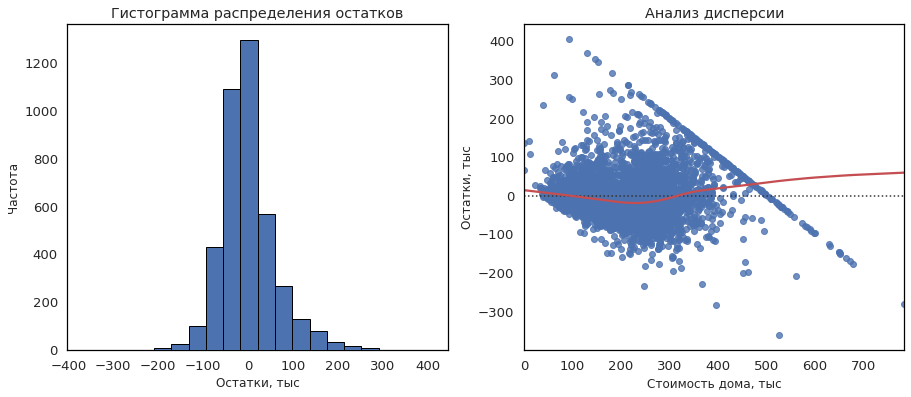

In [54]:
resids(pred_all)

Остатки распределены нормально, дисперсия более менее равномерно, кроме очень дорогих домов

### Модель без категориальных признаков

#### Важность признаков

In [55]:
lr_no_cat.bestModel.stages[6].coefficients

DenseVector([0.096, 0.0321, 0.021, -0.1464, 0.1136, 0.4331, -0.0165, 0.1003, -0.2309])

In [56]:
feature_importance = sorted(list(zip(num_cols, 
                                     map(abs, lr_no_cat.bestModel.stages[6].coefficients))), 
                            key=lambda x: x[1], reverse=True)

print('Влияние числовых признаков')
for feature, importance in feature_importance:
    print(f'{feature}: {importance:.3f}')

Влияние числовых признаков
median_income_log: 0.433
population_in_household: 0.231
population: 0.146
households: 0.114
bedroom_index: 0.100
housing_median_age: 0.096
total_rooms: 0.032
total_bedrooms: 0.021
rooms_per_household: 0.017


Сильнее всего влияет медианный доход и количество людей в массиве, они поменялись местами по значимости по сравнению с полной моделью

#### Анализ остатков и дисперсии

RMSE на тестовых данных: 74438
MAE на тестовых данных: 55169
R2 на тестовых данных: 0.588


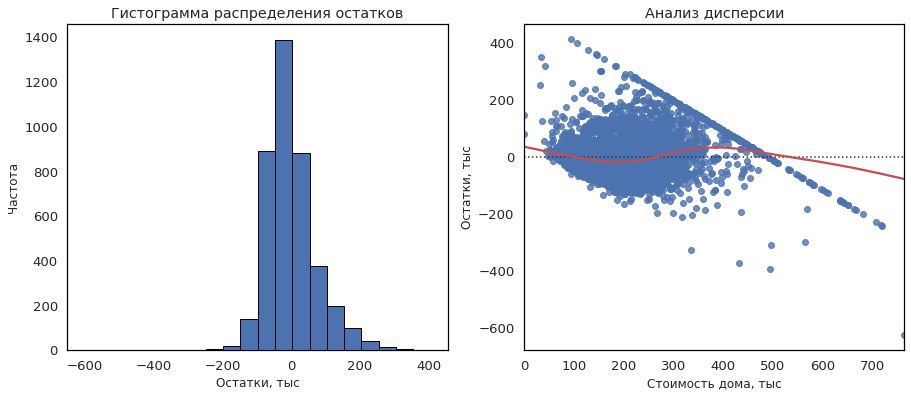

In [57]:
resids(pred_no_cat)

У остатков есть выбросы в дорогих домах, из-за этого появляется хвост слева, дисперсия такая же как и в полной модели. А данная модель больше недооценивает дома в дорогом сегмненте

### Вывод

Модель без категориальных признаков показывает результаты хуже, чем модель со всеми признаками


- **Полная модель**
    - Метрики
        - RMSE - 63404
        - MAE - 45028
        - R2 - 0.701
    - Топ важных признаков
    - `geocluster` - до 0.845
    - `population_in_household` - 0.664
    - `median_income_log`- 0.323


- **Модель без категориальных признаков**
    - Метрики
        - RMSE - 74438
        - MAE - 55169
        - R2 - 0.588
    - Топ важных признаков
    - `median_income_log`- 0.433
    - `population_in_household` - 0.231

In [58]:
spark.stop();

## Общие выводы

В результате работы над проектом на основе обработанных данных были созданы две модели предсказания стоимости жилья в Калифорнии 1990-х (с полным набором признаков и без категориальных признаков). Исследование проводилось с помощью методов pySpark. Подбор моделей проводился с помощью GridParam и кросс-валидацией с 3 фолдами. Проведено сравнение моделей, где модель с полным набором признаков показала лучшие результаты. Касательно построения графиков, если бы массив был достаточно большой, то брали бы просто sample от него, чтобы посмотреть на распределение, матрицу корреляции построили через histogrammar

- **Исходные данные**
    - В таблице 20640 записей
    - 9 числовых признаков
    - 1 строковый - `ocean_proximity`
    - 207 пропусков в `total_bedrooms` - заполнили количеством домов в соответствубщем массиве
    
    
- **Исследовательский анализ**
    - Дополнительные признаки
        - Преобразовали `longitude` и `latitude` с помощью кластеризации в `geocluster`, разбив все координаты на 17 кластеров
        - `rooms_per_household` - отношение количества комнат к количеству домовладений
        - `bedroom_index` - отношение количества спален к общему количеству комнат
        - `population_in_household` - отношение количества жителей к количеству домовладений
        - `median_income_log` - так как генеральная совокупность доходов логнормальная
        - в `ocean_proximity` объединили категорию `ISLAND` с `NEAR BAY`, потому что это скорее всего `Treasure Island` и там всего 0.02 % объектов
    - Медианный портрет домовладения
        - возраст домовладения - 29 лет
        - количество комнат - 2127
        - спален - 435
        - жильцов - 1166
        - владений - 409
        - медианный доход жильцов - 3.5 тыс. USD в месяц
        - медианная стоимость жилья - 180 тыс. USD
        - менее часа езды от океана
        - находится где-то в пригороде ЛА или в самом Городе
        

- **Поиск модели**
    - Построили две модели (с полным наборо признаков и без категориальных признаков)
    - Использовали GridParam и кроссвалидацию с 3 фолдами
    - Вместо обычного логрега использовали GeneralizedLinearRegression со связью с целевым признаком `log`
    - Использовался пайплайн
        - `cat_features`: `StringIndexer` -> `OHE` -> `VectorAssembler`
        - `num_features`: `VectorAssembler` -> `StandardScaler`
        - `VectorAssembler` (`cat_features`, `num_features`)
        - `LR`
        
        
- **Анализ моделей**
    - Модель без категориальных признаков показывает результаты хуже, чем модель со всеми признаками
    - Наиболее важным оказался построенный признак `geocluster`
    - Из числовых признаков сильнее всего влияют медианный доход и количество людей в массиве, они меняются местами по значимости в зависимости от модели
    - Категориальные признаки позволяют лучше предсказывать стоимость дорогого жилья, поэтому для полной модели медианный доход становится менее важным, чем количество людей на дом, то есть явно от многоквартирног типа переход к частным домам и дюплексам в городах вроде ЛА или Сан-Франциско


- **Полная модель**
    - Метрики
        - RMSE - 63404
        - MAE - 45028
        - R2 - 0.701
    - Топ важных признаков
    - `geocluster` - до 0.845
    - `population_in_household` - 0.664
    - `median_income_log`- 0.323


- **Модель без категориальных признаков**
    - Метрики
        - RMSE - 74438
        - MAE - 55169
        - R2 - 0.588
    - Топ важных признаков
    - `median_income_log`- 0.433
    - `population_in_household` - 0.231
    
    
- **Возможные улучшения модели**
    - Можно попробовать использовать другой подход кластеризации
    - Возможно поможет бинаризация возраста объектов
    - Другие варианты численных преобразований для использования с другими семействами моделей